In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('Plazas_SinNulos.csv') 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                304 non-null    int64  
 1   Fecha Origen                              304 non-null    str    
 2   Nombre                                    304 non-null    str    
 3   Producto                                  304 non-null    str    
 4   Asesor                                    304 non-null    str    
 5   Origen                                    304 non-null    str    
 6   Seguimiento                               304 non-null    str    
 7   Cita efetiva                              304 non-null    str    
 8   PDM                                       304 non-null    float64
 9   SDC                                       304 non-null    float64
 10  Estatus                                   304 non

In [4]:
#Se elimina la columna 'Unnamed: 0' que es un índice innecesario
df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
valores_nulos=df.isnull().sum()
valores_nulos

Fecha Origen                                0
Nombre                                      0
Producto                                    0
Asesor                                      0
Origen                                      0
Seguimiento                                 0
Cita efetiva                                0
PDM                                         0
SDC                                         0
Estatus                                     0
¿Por que no hay seguimiento?                0
¿Por que no ha visitado la agencia?         0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo solicitud de credito?      0
¿Por que no se ha formalizado la compra?    0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Fecha Origen                              304 non-null    str    
 1   Nombre                                    304 non-null    str    
 2   Producto                                  304 non-null    str    
 3   Asesor                                    304 non-null    str    
 4   Origen                                    304 non-null    str    
 5   Seguimiento                               304 non-null    str    
 6   Cita efetiva                              304 non-null    str    
 7   PDM                                       304 non-null    float64
 8   SDC                                       304 non-null    float64
 9   Estatus                                   304 non-null    str    
 10  ¿Por que no hay seguimiento?              304 non

In [ ]:
# Creo 2 dataframes para poder procesar los outliers
# Variables cuantitativas
cuantitativas = df.iloc[:, 7:9]
# Variables cualitativas
cualitativas = pd.concat([df.iloc[:, 0:7], df.iloc[:, 9:15]], axis=1)

<Figure size 1500x800 with 0 Axes>

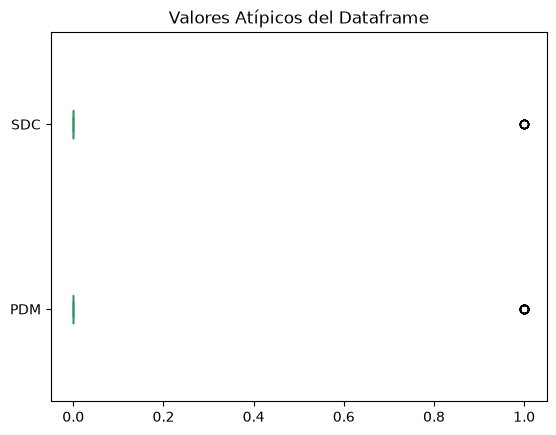

In [9]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [14]:
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido PDM    0.831098
SDC    0.538931
dtype: float64
Limite inferior permitido PDM   -0.69294
SDC   -0.47972
dtype: float64


In [15]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
df1= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
df1

,PDM,SDC
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
299,0.0,0.0
300,0.0,0.0
301,0.0,0.0
302,0.0,0.0


In [16]:
valores_nulos=df1.isnull().sum()
valores_nulos

PDM    21
SDC     9
dtype: int64

In [17]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
df_clean=df1.copy()
df_clean=df_clean.fillna(round(df1.mean(),1))
df_clean

,PDM,SDC
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
299,0.0,0.0
300,0.0,0.0
301,0.0,0.0
302,0.0,0.0


In [18]:
valores_nulos=df_clean.isnull().sum()
valores_nulos

PDM    0
SDC    0
dtype: int64

In [19]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido PDM    0.0
SDC    0.0
dtype: float64
Limite inferior permitido PDM    0.0
SDC    0.0
dtype: float64


In [20]:
#Obtenemos datos limpios del Dataframe
df_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
df_iqr

,PDM,SDC
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
299,0.0,0.0
300,0.0,0.0
301,0.0,0.0
302,0.0,0.0


In [21]:
valores_nulos=df_iqr.isnull().sum()
valores_nulos

PDM    21
SDC     9
dtype: int64

In [30]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
df1_iqr=df_iqr.copy()
df1_iqr=df1_iqr.fillna(round(df_iqr.median(),1))
df1_iqr

,PDM,SDC
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
299,0.0,0.0
300,0.0,0.0
301,0.0,0.0
302,0.0,0.0


In [31]:
Datos_limpios = pd.concat([cualitativas, df_iqr], axis=1)
Datos_limpios

,Fecha Origen,Nombre,Producto,Asesor,Origen,Seguimiento,Cita efetiva,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,PDM,SDC
0,2025-05-06 18:30:00,Alejandro Fernandez,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,1.0,0.0,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",No hay registro,No hay registro,No hay registro,0.0,0.0
1,2025-05-06 18:00:00,David Israel,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,1.0,0.0,Finalizado,Si hay seguimiento,Dejo de contestar,No hay registro,No hay registro,No hay registro,0.0,0.0
2,2025-05-06 13:50:00,Rosendo Ceron,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No hay registro,No hay registro,No hay registro,0.0,0.0
3,2025-05-06 13:47:00,Fausto Ochoa Martinez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No hay registro,No hay registro,No hay registro,0.0,0.0
4,2025-05-06 13:43:00,Brigida Lara Perez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No hay registro,No hay registro,No hay registro,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,2025-06-09 15:30:00,Miguel Fernandez,GS8,PEDRO ANTONIO CINTO DE GANTE,PLAZA ANGELOPOLIS,0.0,0.0,False,No hay registro,No hay registro,No hay registro,No hay registro,No hay registro,0.0,0.0
300,2025-06-09 13:15:00,Luis,EMZOOM,SERGIO RAYMUNDO VAZQUEZ SANCHEZ,GALERIAS TLAXCALA,0.0,0.0,False,No hay registro,No hay registro,No hay registro,No hay registro,No hay registro,0.0,0.0
301,2025-06-09 13:14:00,Rolando Manrique,EMZOOM,SERGIO RAYMUNDO VAZQUEZ SANCHEZ,Gran Patio Tlaxcala,0.0,0.0,False,No hay registro,No hay registro,No hay registro,No hay registro,No hay registro,0.0,0.0
302,2025-06-09 12:50:00,Odilia Cuamatzi Bautista,GS8,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,0.0,0.0,False,No hay registro,No hay registro,No hay registro,No hay registro,No hay registro,0.0,0.0


In [32]:
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Fecha Origen                                0
Nombre                                      0
Producto                                    0
Asesor                                      0
Origen                                      0
Seguimiento                                 0
Cita efetiva                                0
Estatus                                     0
¿Por que no hay seguimiento?                0
¿Por que no ha visitado la agencia?         0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo solicitud de credito?      0
¿Por que no se ha formalizado la compra?    0
PDM                                         0
SDC                                         0
dtype: int64

In [33]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Plazas_SinAtipicos.csv")